In [1]:
#Importing Libraries
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from src.plant_disease_mlops import settings
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import load_model


<h2>Loading Data

In [15]:
#Dataset Path
train_dir =  Path(settings.base_dir_path,settings.RAW_DATA_DIR_PATH)

In [16]:
# Data augmentation and generator setup (with 20% validation split)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,  
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Training generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Validation generator
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)


Found 4363 images belonging to 4 classes.
Found 1089 images belonging to 4 classes.


In [17]:
# Dynamically determine the number of classes from the folder structure
num_classes = len(train_generator.class_indices)
print("Number of classes in the dataset:", num_classes)

Number of classes in the dataset: 4


In [18]:
class_counts = {}

for class_dir in sorted(train_dir.iterdir()):
    if class_dir.is_dir():
        images = [
            file for file in class_dir.iterdir()
            if file.suffix.lower() in {".jpg", ".jpeg", ".png"}
        ]
        class_counts[class_dir.name] = len(images)

class_counts

{'Tomato___Early_blight': 1000,
 'Tomato___healthy': 1591,
 'Tomato___Late_blight': 1909,
 'Tomato___Leaf_Mold': 952}

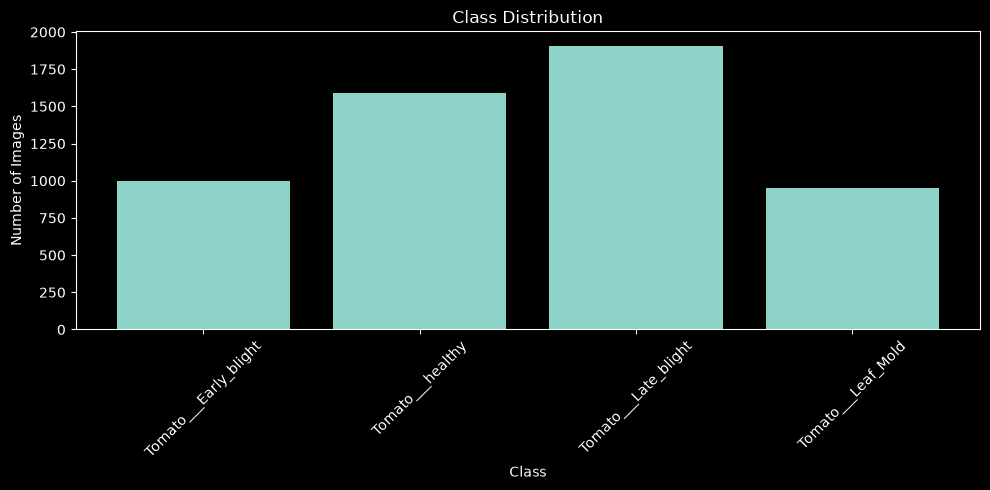

In [19]:
plt.figure(figsize=(10, 5))

plt.bar(class_counts.keys(), class_counts.values())

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
total_images = sum(class_counts.values())

class_percentages = {
    class_name: count / total_images * 100
    for class_name, count in class_counts.items()
}

class_percentages

{'Tomato___Early_blight': 18.34189288334556,
 'Tomato___healthy': 29.18195157740279,
 'Tomato___Late_blight': 35.01467351430668,
 'Tomato___Leaf_Mold': 17.461482024944974}

<h2>Transfer Learning

In [21]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)
base_model.trainable = False  # Freeze the base model initially

In [22]:
model = Sequential([
    base_model,
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')  # Output layer now has 39 units
])

In [23]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
# Define callbacks for early stopping and saving the best model.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True
)

In [11]:
# Initial training phase: train only the top layers.
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    epochs=30,
    callbacks=[early_stop, checkpoint]
)


KeyboardInterrupt



<h2>Fine-Tuning

In [12]:
#Freezing 1st 100 layers
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

In [13]:
# Recompile the model with a lower learning rate for fine-tuning.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
# Fine-tune the model for additional epochs.
history_fine = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    epochs=10,  # Adjust epochs as needed based on validation performance.
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.9026 - loss: 0.2771 - val_accuracy: 0.9246 - val_loss: 0.1965
Epoch 2/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 33s 241ms/step - accuracy: 0.9375 - loss: 0.3738 - val_accuracy: 0.9265 - val_loss: 0.2037
Epoch 3/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 956ms/step - accuracy: 0.9035 - loss: 0.2745

136/136 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - accuracy: 0.9035 - loss: 0.2745 - val_accuracy: 0.9347 - val_loss: 0.1889
Epoch 4/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 34s 245ms/step - accuracy: 0.9688 - loss: 0.1503 - val_accuracy: 0.9283 - val_loss: 0.2047
Epoch 5/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 957ms/step - accuracy: 0.9023 - loss: 0.2654

136/136 ━━━━━━━━━━━━━━━━━━━━ 164s 1s/step - accuracy: 0.9023 - loss: 0.2654 - val_accuracy: 0.9384 - val_loss: 0.1806
Epoch 6/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 34s 248ms/step - accuracy: 0.9062 - loss: 0.2963 - val_accuracy: 0.9384 - val_loss: 0.1939
Epoch 7/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 953ms/step - accuracy: 0.9169 - loss: 0.2476

136/136 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - accuracy: 0.9169 - loss: 0.2476 - val_accuracy: 0.9311 - val_loss: 0.1763
Epoch 8/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 34s 244ms/step - accuracy: 0.9375 - loss: 0.2082 - val_accuracy: 0.9283 - val_loss: 0.1928
Epoch 9/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 162s 1s/step - accuracy: 0.9111 - loss: 0.2552 - val_accuracy: 0.9421 - val_loss: 0.1820
Epoch 10/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 33s 238ms/step - accuracy: 0.9062 - loss: 0.1204 - val_accuracy: 0.9329 - val_loss: 0.1904


In [15]:
print("Training complete. Best model saved as 'best_model.h5'.")

Training complete. Best model saved as 'best_model.h5'.


## Hyperparameter tuning

In [23]:
def build_model(hp):

    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet",
        pooling="avg",
    )

    # Fine-tuning
    base_model.trainable = True

    # عدد الطبقات التي نريد تدريبها من نهاية MobileNetV2
    fine_tune_layers = hp.Int(
        "fine_tune_layers",
        min_value=10,
        max_value=50,
        step=10,
    )

    for layer in base_model.layers[:-fine_tune_layers]:
        layer.trainable = False

    x = base_model.output

    units = hp.Int(
        "dense_units",
        min_value=64,
        max_value=256,
        step=64,
    )

    dropout = hp.Float(
        "dropout",
        min_value=0.2,
        max_value=0.5,
        step=0.1,
    )

    x = layers.Dense(units, activation="relu")(x)
    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(
        train_generator.num_classes,
        activation="softmax",
    )(x)

    model = Model(
        inputs=base_model.input,
        outputs=outputs,
    )

    learning_rate = hp.Choice(
        "learning_rate",
        values=[1e-5, 5e-5, 1e-4],
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model

In [24]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=10,
    directory="tuner_results",
    project_name="plant_disease",
)

In [26]:
tuner.search(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop],
)

Trial 10 Complete [00h 26m 47s]
val_accuracy: 0.8503214120864868

Best val_accuracy So Far: 0.9641873240470886
Total elapsed time: 04h 03m 17s


In [27]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

In [28]:
print("Learning rate:", best_hps.get("learning_rate"))
print("Dense units:", best_hps.get("dense_units"))
print("Dropout:", best_hps.get("dropout"))
print("Fine-tune layers:", best_hps.get("fine_tune_layers"))

Learning rate: 0.0001
Dense units: 192
Dropout: 0.30000000000000004
Fine-tune layers: 50


In [31]:
best_model = tuner.hypermodel.build(best_hps)

In [32]:
best_model = tuner.get_best_models(num_models=1)[0]
best_model.save("best_model_hyper.keras")

G:\New folder (3)\MLops\mini-project-2\plant-disease-mlops\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 110 variables. 
  saveable.load_own_variables(store)


<h2>Examples

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


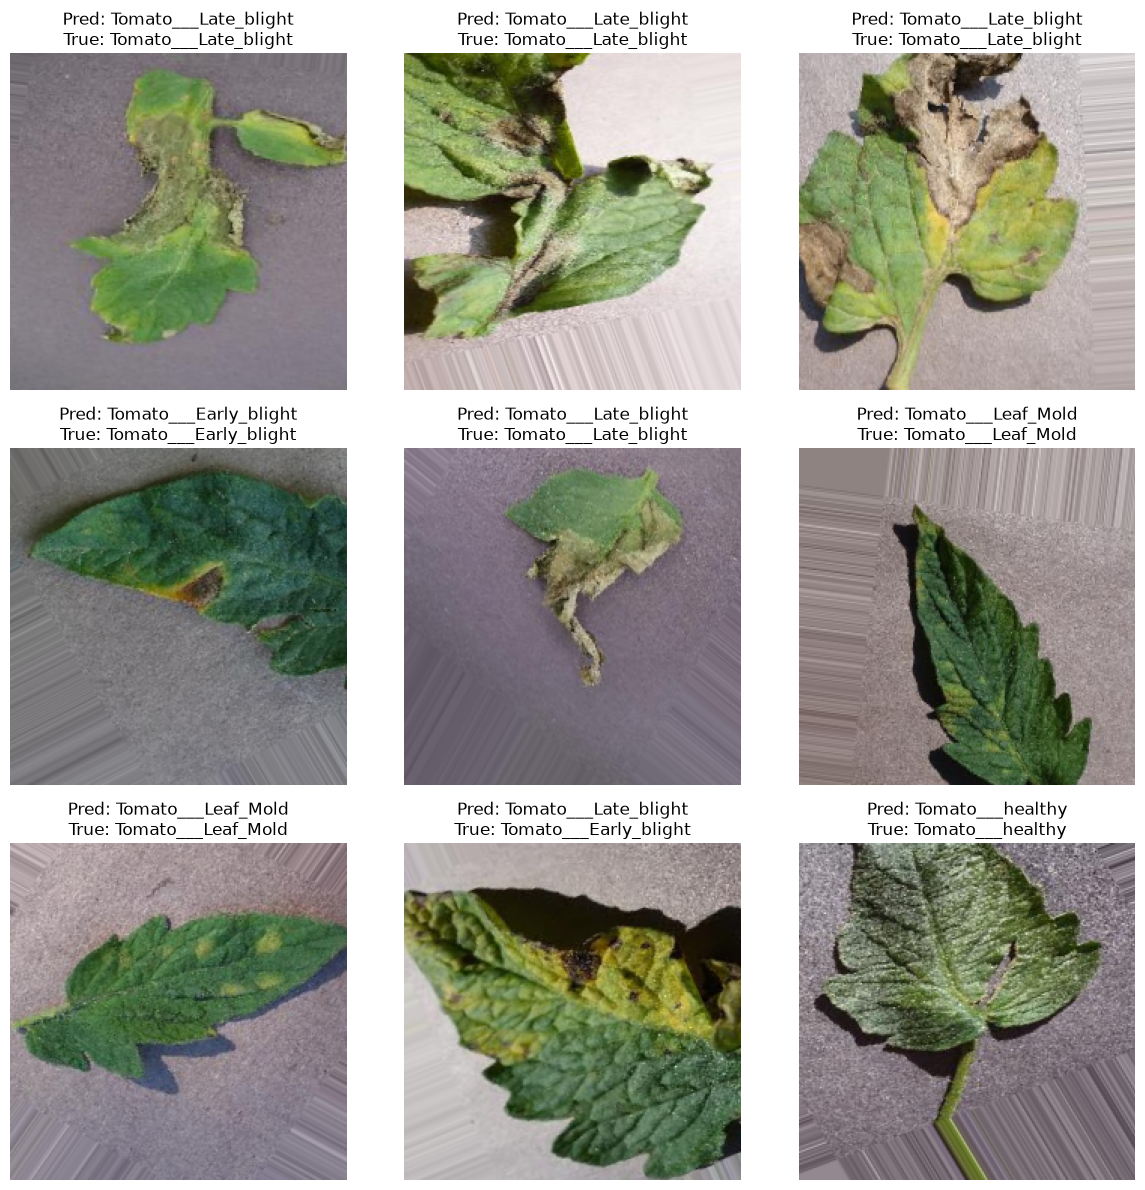

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Get a single batch of images and labels from the validation generator.
# If you prefer, you could also use your training generator or load images from disk.
x_val, y_val = next(val_generator)

# Use the trained model to predict the classes for these images.
predictions = model.predict(x_val)

# Convert the prediction probabilities into class labels (indices).
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_val, axis=1)

# Retrieve class names from the training generator's mapping.
# This assumes that your train_generator was set up to automatically map folder names to indices.
class_indices = train_generator.class_indices
# Invert the dictionary to map indices back to class names.
class_names = {v: k for k, v in class_indices.items()}

# Plot a grid of 9 sample images along with their predicted and true labels.
plt.figure(figsize=(12, 12))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_val[i])
    plt.title(f"Pred: {class_names[predicted_classes[i]]}\nTrue: {class_names[true_classes[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()
